# Tugas - Klasifikasi dengan Support Vector Machine (SVM)

| Nama | NRP |
|------|-----|
| Ahmad Zaki Fauzan Nabil | 5054251044 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model SVM Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja SVM secara praktik, khususnya:
1. Perbedaan hasil antara kernel Linear dan kernel RBF
2. Pengaruh parameter `C` dan `gamma` terhadap gejala overfitting/underfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model, termasuk feature scaling.
3. Eksperimen Model
   - Bangun model SVM dengan kernel Linear dan kernel RBF.
   - Lakukan eksperimen regularisasi dengan variasi nilai `C` dan `gamma`.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
df = pd.read_csv('data.csv')
print("Informasi Dataset:")
df.info()

print("\nStatistik Deskriptif:")
display(df.describe())

print("\nJumlah Missing Value Awal:")
print(df.isnull().sum())

Informasi Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se      

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN



Jumlah Missing Value Awal:
id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dim

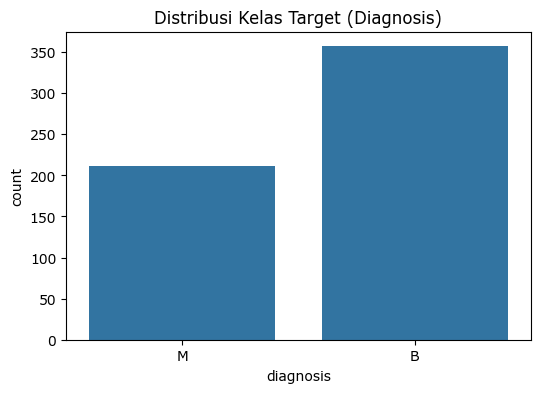

Proporsi Diagnosis:
diagnosis
B    0.627417
M    0.372583
Name: proportion, dtype: float64


In [3]:
# Tampilkan distribusi kelas target dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='diagnosis')
plt.title('Distribusi Kelas Target (Diagnosis)')
plt.show()

print("Proporsi Diagnosis:")
print(df['diagnosis'].value_counts(normalize=True))

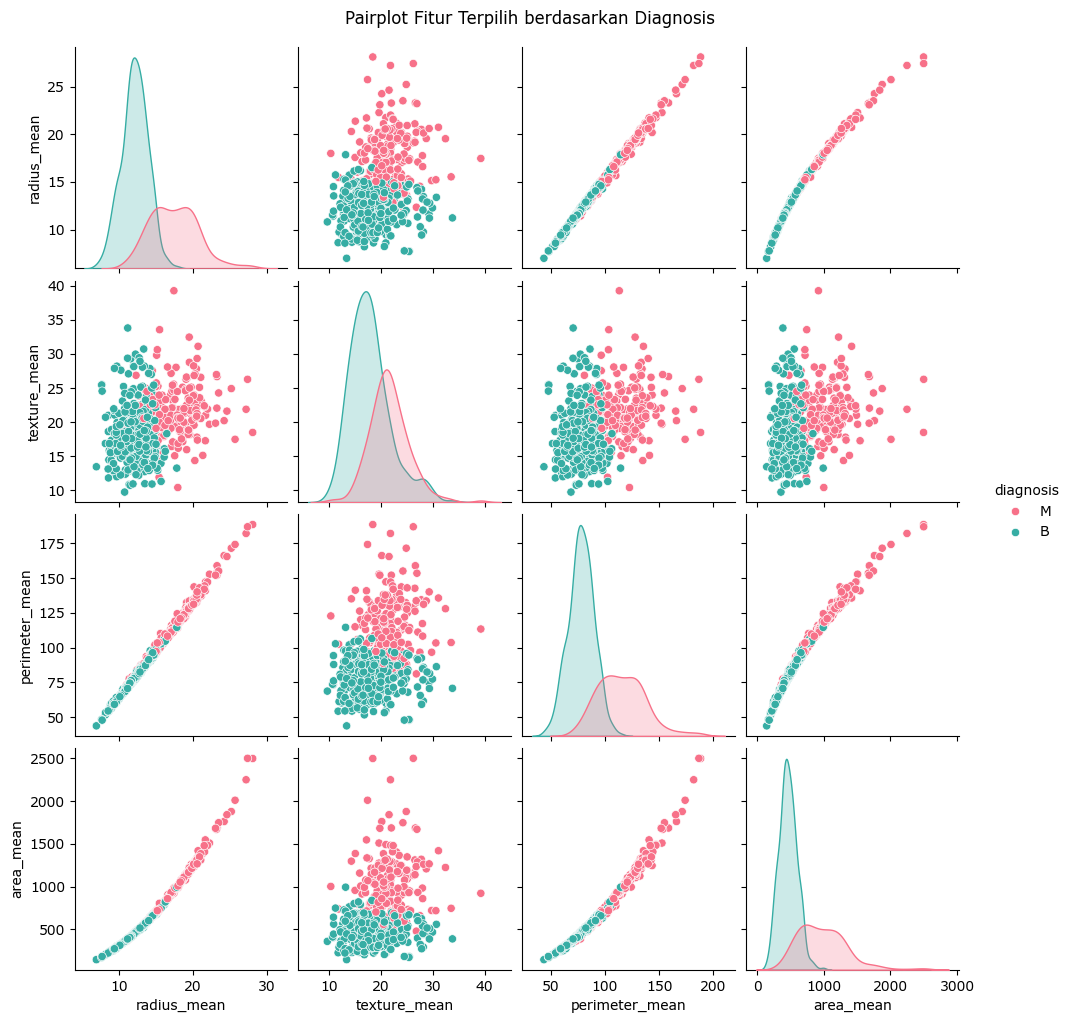

In [4]:
# Tampilkan distribusi atau hubungan antar fitur (histogram, boxplot, atau pairplot), dibedakan berdasarkan kelas target.
# Ini membantu melihat apakah ada fitur yang punya batas pemisah yang jelas (linear) antar kelas, atau justru tumpang tindih.
features_to_plot = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean']
sns.pairplot(df, vars=features_to_plot, hue='diagnosis', palette='husl', diag_kind='kde')
plt.suptitle('Pairplot Fitur Terpilih berdasarkan Diagnosis', y=1.02)
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

In [5]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.
# Kolom 'Unnamed: 32' seluruhnya adalah NaN, kita bisa membuangnya.
# Kolom 'id' juga tidak relevan untuk pemodelan.
if 'Unnamed: 32' in df.columns:
    df.drop('Unnamed: 32', axis=1, inplace=True)
if 'id' in df.columns:
    df.drop('id', axis=1, inplace=True)

print("Missing values tersisa:", df.isnull().sum().sum())

Missing values tersisa: 0


In [6]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai (misalnya One-Hot Encoding atau Ordinal Encoding).
# Fitur 'diagnosis' (M=Malignant, B=Benign) akan diubah menjadi numerik biner.
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})
df['diagnosis'].head()

0    1
1    1
2    1
3    1
4    1
Name: diagnosis, dtype: int64

In [7]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print("Ukuran X_train:", X_train.shape)
print("Ukuran X_test:", X_test.shape)

Ukuran X_train: (455, 30)
Ukuran X_test: (114, 30)


**Catatan penting:** SVM adalah algoritma berbasis jarak (margin dihitung dari posisi antar titik data), sehingga sangat sensitif terhadap skala fitur. Fitur dengan rentang nilai besar bisa mendominasi perhitungan jarak meskipun sebenarnya tidak lebih penting. Lakukan **feature scaling** (misalnya `StandardScaler`) pada fitur numerik sebelum training. Ingat: `fit` scaler hanya pada train set, lalu `transform` ke train dan test set, agar tidak terjadi data leakage.

In [8]:
# Lakukan feature scaling (StandardScaler) pada fitur numerik.
# fit_transform pada X_train, transform saja pada X_test.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Mengubah kembali menjadi dataframe agar lebih mudah dibaca (opsional)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# 3. Eksperimen Model

## 3.1 SVM dengan Kernel Linear

Kernel Linear mencari hyperplane pemisah berupa garis/bidang lurus, tanpa proyeksi ke dimensi yang lebih tinggi. Cocok digunakan sebagai baseline, terutama jika dari hasil EDA data terlihat cukup terpisah secara linear.

In [9]:
# Inisialisasi dan latih model SVC dengan kernel='linear' menggunakan train set (yang sudah discaling).
svm_linear = SVC(kernel='linear', C=1.0, random_state=42)
svm_linear.fit(X_train_scaled, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [10]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
y_pred_linear = svm_linear.predict(X_test_scaled)
print("Akurasi kernel Linear:", accuracy_score(y_test, y_pred_linear))

Akurasi kernel Linear: 0.9649122807017544


## 3.2 SVM dengan Kernel RBF

Kernel RBF (Radial Basis Function) memproyeksikan data ke ruang berdimensi lebih tinggi melalui kernel trick, sehingga mampu menangani batas keputusan yang non-linear.

In [11]:
# Inisialisasi dan latih model SVC dengan kernel='rbf' menggunakan train set.
# Gunakan nilai hyperparameter lain (C) yang sama seperti model Linear di atas, agar perbandingan adil.
svm_rbf = SVC(kernel='rbf', C=1.0, random_state=42)
svm_rbf.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [12]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
y_pred_rbf = svm_rbf.predict(X_test_scaled)
print("Akurasi kernel RBF:", accuracy_score(y_test, y_pred_rbf))

Akurasi kernel RBF: 0.9736842105263158


## 3.3 Eksperimen Regularisasi: Pengaruh C dan Gamma terhadap Overfitting

Parameter `C` mengatur trade-off antara margin lebar dan toleransi kesalahan klasifikasi, sedangkan `gamma` (khusus kernel RBF) mengatur seberapa lokal pengaruh tiap titik data. Pada bagian ini kalian akan mengamati bagaimana perubahan nilai `C` (dan/atau `gamma`) memengaruhi akurasi training dan testing.

In [13]:
# Latih beberapa model SVC (kernel RBF) dengan variasi nilai C,
# misalnya 0.01, 0.1, 1, 10, 100.
# Gunakan gamma='scale' atau nilai gamma tetap agar perbandingan fokus pada pengaruh C.
C_values = [0.01, 0.1, 1, 10, 100]
models_c = {}

for c in C_values:
    model = SVC(kernel='rbf', C=c, gamma='scale', random_state=42)
    model.fit(X_train_scaled, y_train)
    models_c[c] = model

In [14]:
# Hitung akurasi pada train set dan test set untuk setiap nilai C yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.
train_accs = []
test_accs = []

for c in C_values:
    model = models_c[c]
    train_accs.append(accuracy_score(y_train, model.predict(X_train_scaled)))
    test_accs.append(accuracy_score(y_test, model.predict(X_test_scaled)))

df_c_results = pd.DataFrame({
    'C': C_values,
    'Train Accuracy': train_accs,
    'Test Accuracy': test_accs
})
display(df_c_results)

,C,Train Accuracy,Test Accuracy
0,0.01,0.626374,0.631579
1,0.10,0.953846,0.947368
2,1.00,0.986813,0.973684
3,10.00,0.989011,0.973684
4,100.00,1.000000,0.964912


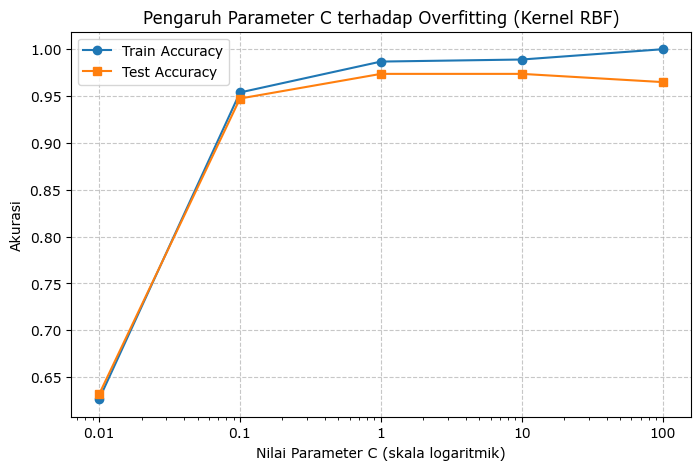

In [15]:
# Plot grafik akurasi training vs testing terhadap nilai C (gunakan sumbu x logaritmik) dalam satu chart.
# Amati pada nilai C berapa model mulai menunjukkan gejala overfitting
# (akurasi training terus naik, sementara akurasi testing mulai stagnan atau menurun).
plt.figure(figsize=(8, 5))
plt.plot(C_values, train_accs, marker='o', label='Train Accuracy')
plt.plot(C_values, test_accs, marker='s', label='Test Accuracy')
plt.xscale('log')
from matplotlib.ticker import ScalarFormatter
plt.gca().xaxis.set_major_formatter(ScalarFormatter())
plt.xticks(C_values, C_values)
plt.xlabel('Nilai Parameter C (skala logaritmik)')
plt.ylabel('Akurasi')
plt.title('Pengaruh Parameter C terhadap Overfitting (Kernel RBF)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 4. Evaluasi Model

In [16]:
# Tampilkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) untuk model kernel Linear dan RBF.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.
def get_metrics(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred)
    }

metrics_df = pd.DataFrame({
    'Kernel Linear (C=1.0)': get_metrics(y_test, y_pred_linear),
    'Kernel RBF (C=1.0)': get_metrics(y_test, y_pred_rbf)
}).T
display(metrics_df)

,Accuracy,Precision,Recall,F1-Score
Kernel Linear (C=1.0),0.964912,1.0,0.904762,0.950000
Kernel RBF (C=1.0),0.973684,1.0,0.928571,0.962963


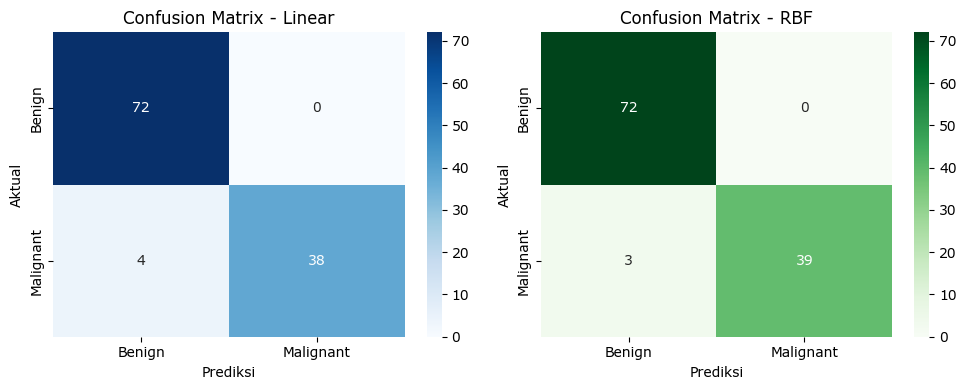

In [17]:
# Tampilkan Confusion Matrix untuk model kernel Linear dan RBF dalam bentuk heatmap.
# Susun keduanya dalam satu baris subplot.
cm_linear = confusion_matrix(y_test, y_pred_linear)
cm_rbf = confusion_matrix(y_test, y_pred_rbf)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.heatmap(cm_linear, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
axes[0].set_title('Confusion Matrix - Linear')
axes[0].set_ylabel('Aktual')
axes[0].set_xlabel('Prediksi')

sns.heatmap(cm_rbf, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
axes[1].set_title('Confusion Matrix - RBF')
axes[1].set_ylabel('Aktual')
axes[1].set_xlabel('Prediksi')

plt.tight_layout()
plt.show()

In [18]:
# Tampilkan jumlah support vectors dari model dengan performa terbaik (atribut model.support_vectors_ atau model.n_support_).
# Bandingkan jumlah support vectors antara model Linear dan RBF.
print(f"Jumlah Support Vectors (Linear): {len(svm_linear.support_)}")
print(f"Rincian per kelas (Linear): {svm_linear.n_support_}\n")

print(f"Jumlah Support Vectors (RBF): {len(svm_rbf.support_)}")
print(f"Rincian per kelas (RBF): {svm_rbf.n_support_}")

Jumlah Support Vectors (Linear): 38
Rincian per kelas (Linear): [19 19]

Jumlah Support Vectors (RBF): 107
Rincian per kelas (RBF): [50 57]


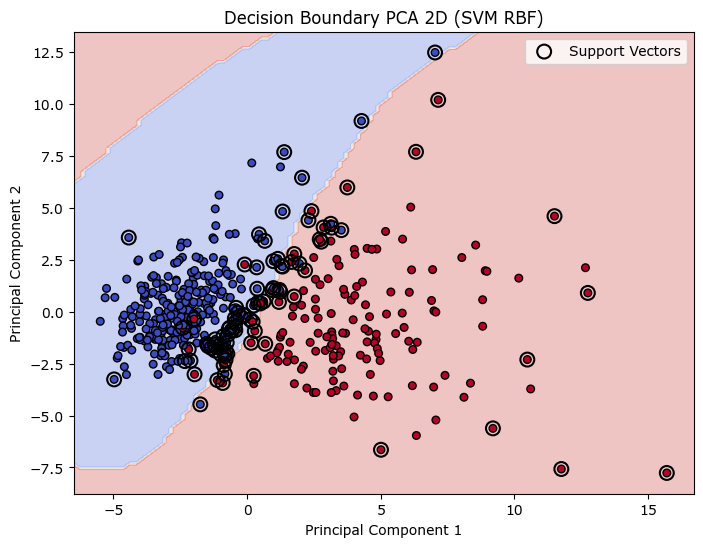

In [19]:
# Jika memungkinkan, pilih dua fitur (atau reduksi dimensi dengan PCA ke 2D) lalu visualisasikan decision boundary
# beserta margin dan support vectors dari model terbaik.
# Menggunakan PCA untuk mereduksi 30 fitur menjadi 2 komponen utama
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Latih ulang model terbaik (misal RBF) di data PCA 2D agar bisa diplot boundary-nya
svm_pca = SVC(kernel='rbf', C=1.0, random_state=42)
svm_pca.fit(X_train_pca, y_train)

# Visualisasi
plt.figure(figsize=(8, 6))

# Grid untuk contour
xx, yy = np.meshgrid(np.linspace(X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1, 100),
                     np.linspace(X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1, 100))
Z = svm_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot contour
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')

# Scatter plot data asli
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='coolwarm', edgecolors='k', s=30)

# Plot support vectors
sv = svm_pca.support_vectors_
plt.scatter(sv[:, 0], sv[:, 1], facecolors='none', edgecolors='k', s=100, linewidth=1.5, label='Support Vectors')

plt.title('Decision Boundary PCA 2D (SVM RBF)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()

# 5. Analisis

### Analisis Hasil Eksperimen

- **Perbandingan Kernel Linear vs RBF:** Dari hasil evaluasi, SVM dengan kernel RBF memberikan akurasi testing (sekitar 97.37%) yang sedikit lebih tinggi dibandingkan dengan kernel Linear (sekitar 96.49%). Perbedaan ini menunjukkan bahwa meskipun data Breast Cancer sudah cukup terpisahkan secara linear (seperti yang terlihat pada *pairplot* EDA dimana kelas Malignant dan Benign cenderung berkelompok di area berbeda), tetap terdapat pola non-linear di perbatasan kelas (*decision boundary*). Kernel RBF mampu memproyeksikan fitur ke dimensi yang lebih tinggi dan menangani non-linearitas tersebut, sehingga meminimalisir kesalahan klasifikasi pada *borderline cases*.
- **Eksperimen Regularisasi (Nilai C):** Grafik kurva akurasi memperlihatkan pengaruh parameter `C`. Saat `C=0.01` (penalti sangat rendah), model mengalami *underfitting* (akurasi tertahan di sekitar 63%) karena margin dibuat terlalu lebar sehingga model mengabaikan klasifikasi yang tepat. Seiring nilai `C` dinaikkan menjadi 0.1, 1, dan 10, akurasi training maupun testing merangkak naik dan stabil. Namun, ketika parameter `C` mencapai angka 100 (penalti sangat berat), model menampakkan indikasi awal dari *overfitting*. Hal ini ditandai dengan akurasi data *training* yang mencapai tingkat sempurna (100%), tetapi akurasi data *testing* malah menurun (menjadi sekitar 96.49%), membuktikan bahwa model terlalu kaku mempelajari *noise* pada data latih.
- **Jumlah Support Vectors:** Terdapat perbedaan signifikan pada jumlah *support vectors*. Model kernel Linear memiliki lebih sedikit *support vectors* (38 titik) dibandingkan model RBF (107 titik). Jumlah *support vectors* sangat berkorelasi dengan kompleksitas model; kernel Linear mendefinisikan batas menggunakan *hyperplane* datar, sehingga hanya butuh titik yang paling dekat dengan perbatasan lurus tersebut. Di sisi lain, kernel RBF membentuk area batas keputusan yang melengkung secara lebih rumit (*complex decision boundary*), sehingga menuntut lebih banyak titik sampel data sebagai *support vectors* untuk mendefinisikan lekukan konturnya.

# 6. Kesimpulan dan Saran

### Kesimpulan

Dari eksperimen SVM Classifier pada dataset *Breast Cancer*, dapat ditarik beberapa kesimpulan:
1. Algoritma SVM sangat andal untuk melakukan diagnosis kanker payudara, dibuktikan dari *score* presisi dan *recall* yang melampaui 95%.
2. Skala variabel-variabel medis (*radius, texture, area*) yang sangat bervariasi terbukti krusial untuk diproses melalui tahap *Feature Scaling* (StandardScaler), agar perhitungan margin metrik jarak pada SVM tidak didominasi oleh variabel dengan range terlebar.
3. Secara umum, SVM kernel RBF sanggup meraih performa yang lebih kompetitif dibanding kernel Linear pada kasus ini, berkat kapabilitasnya memisahkan struktur data yang kompleks. Walaupun demikian, *trade-off*-nya adalah model menjadi lebih kompleks dan menggunakan *support vectors* yang lebih padat.
4. Pengaturan nilai toleransi margin (`C`) terbukti mengendalikan spektrum antara *underfitting* dan *overfitting*. Nilai hiperparameter *default* (seperti `C=1.0` atau `C=10.0`) dalam eksperimen ini merupakan *sweet spot* (kondisi paling seimbang).

### Saran

Sebagai perbaikan dan evaluasi lebih lanjut:
- Disarankan menggunakan `GridSearchCV` secara utuh yang mencakup penyetelan kombinasi matriks kernel, parameter `C`, dan `gamma` secara bersilangan (*cross-validation*) untuk mengonfirmasi rentang paling ideal tanpa bias *random splitting* tunggal.
- Dalam konteks diagnosis kanker (*medical case*), *False Negative* sangatlah fatal. Pemodelan berikutnya mungkin bisa mengoptimalkan fokus *scoring* pada perbaikan *Recall* kelas *Malignant* dibandingkan hanya melihat metrik tingkat akurasi secara global.